# Анализ заказов интернет-магазина Olist

## Загрузка данных

In [1]:
import pandas as pd

orders = pd.read_csv('data/olist_orders_dataset.csv')
print(orders.shape)
orders.head()

(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [2]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


## Подготовка данных

In [3]:
date_columns = ["order_purchase_timestamp","order_approved_at","order_delivered_carrier_date","order_delivered_customer_date","order_estimated_delivery_date"]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

orders.dtypes

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [4]:
orders["order_status"].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

## Проверка качества данных
Гипотеза: пропуски в дате доставки — это заказы, которые не были доставлены.

In [5]:
#ищем доставленные заказы, но без даты доставки
delivered_orders = orders[orders["order_status"] == 'delivered'] 
delivered_no_date = delivered_orders[delivered_orders["order_delivered_customer_date"].isna()]

#ищем недоставленные заказы, но с датой доставки
not_delivered_orders = orders[orders["order_status"] != 'delivered']
not_delivered_with_date = not_delivered_orders[not_delivered_orders["order_delivered_customer_date"].notna()]

print('Доставлены, но без даты:', len(delivered_no_date))
print('Не доставлены, но с датой:', len(not_delivered_with_date))

Доставлены, но без даты: 8
Не доставлены, но с датой: 6


**Вывод:** гипотеза подтвердилась. Найдено 14 аномалий: 8 доставленных заказов без даты доставки и 6 недоставленных с датой. Это 0,01% данных, для анализа доставки их исключаем.

In [6]:
clean_delivered = delivered_orders[delivered_orders["order_delivered_customer_date"].notna()]
print(len(clean_delivered))

96470


## Вопрос 1. Заказы и выручка по месяцам

In [7]:
#один заказ можно оплатить несколькими способами, поэтому складываем все оплаты заказа
payments = pd.read_csv("data/olist_order_payments_dataset.csv")
order_revenue = payments.groupby("order_id")["payment_value"].sum().reset_index()

#убираем отменённые и недоступные заказы
valid_orders = orders[orders["order_status"] != "canceled"]
valid_orders = valid_orders[valid_orders["order_status"] != "unavailable"]

#подтягиваем сумму оплаты к каждому заказу 
orders_with_revenue = valid_orders.merge(order_revenue, on="order_id", how="left")
orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,28.62


In [8]:
#вытаскиваем месяц из даты покупки
orders_with_revenue["month"] = orders_with_revenue["order_purchase_timestamp"].dt.to_period("M")

monthly = orders_with_revenue.groupby("month").agg(
    orders_count=("order_id", "count"),
    revenue=("payment_value", "sum")
)
monthly

,orders_count,revenue
month,,
2016-09,2,136.23
2016-10,293,51657.53
2016-12,1,19.62
2017-01,787,137006.76
2017-02,1718,283621.94
2017-03,2617,425656.40
2017-04,2377,405988.38
2017-05,3640,582926.16
2017-06,3205,499827.47


In [9]:
#оставляем только месяцы с полными данными: с января 2017 по август 2018
monthly_clean = monthly.loc["2017-01":"2018-08"]
monthly_clean

,orders_count,revenue
month,,
2017-01,787,137006.76
2017-02,1718,283621.94
2017-03,2617,425656.40
2017-04,2377,405988.38
2017-05,3640,582926.16
2017-06,3205,499827.47
2017-07,3946,578858.58
2017-08,4272,662071.77
2017-09,4227,717195.22


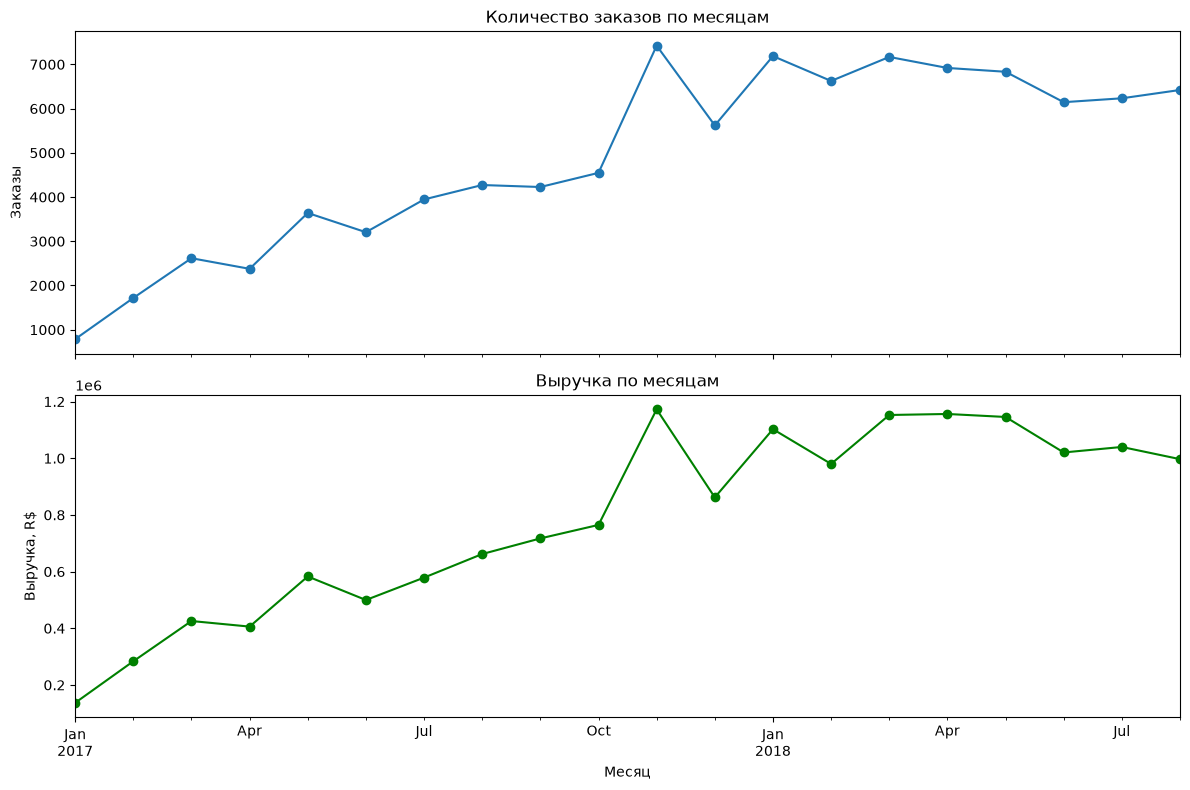

In [10]:
import matplotlib.pyplot as plt

#два графика друг под другом с общей осью месяцев
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

#верхний график: количество заказов
monthly_clean["orders_count"].plot(ax=axes[0], marker="o")
axes[0].set_title("Количество заказов по месяцам")
axes[0].set_ylabel("Заказы")

#нижний график: выручка
monthly_clean["revenue"].plot(ax=axes[1], marker="o", color="green")
axes[1].set_title("Выручка по месяцам")
axes[1].set_ylabel("Выручка, R$")
axes[1].set_xlabel("Месяц")

plt.tight_layout()
plt.show()

**Вывод:**
- Количество заказов и выручка движутся синхронно: средний чек стабилен, рост выручки обеспечен ростом числа заказов.
- В 2017 году компания активно росла: с ~800 заказов в январе до ~4 500 в октябре.
- В ноябре 2017 — резкий пик (~7 400 заказов), вероятно из-за Чёрной пятницы (24.11.2017). В декабре продажи вернулись к тренду, но остались выше дооктябрьского уровня.
- В 2018 году рост остановился: продажи вышли на плато ~6–7 тыс. заказов и ~1–1,15 млн R$ в месяц, с лёгким снижением летом.

## Вопрос 2. Повторные покупки

In [11]:
customers = pd.read_csv("data/olist_customers_dataset.csv")

#подтягиваем к каждому заказу реального покупателя (customer_unique_id) и считаем количество заказов каждого
customer_orders = valid_orders.merge(customers, on = ['customer_id'], how = 'left')
orders_per_customer = customer_orders.groupby("customer_unique_id")["customer_id"].count()

#покупатели, у которых больше одного заказа
repeat_customers = orders_per_customer[orders_per_customer > 1]


total = len(orders_per_customer)
repeat = len(repeat_customers)

print("Всего покупателей:", total)
print("Купили повторно:", repeat)
print("Доля повторных:", round(repeat / total * 100, 1), "%")

Всего покупателей: 94990
Купили повторно: 2888
Доля повторных: 3.0 %


In [12]:
orders_per_customer.value_counts().sort_index()

customer_id
1     92102
2      2652
3       188
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

**Вывод:**
- Из 94 990 покупателей повторно купили только 2 888 — это **3%**. 97% клиентов сделали ровно один заказ.
- Среди повторных почти все купили дважды; есть выброс — покупатель с 16 заказами (вероятно, перекупщик или бизнес).
- Возможные причины: короткий период данных (~2 года) и популярность товаров, которые покупают редко (мебель, товары для дома).
- Рост компании держится почти полностью на новых клиентах. Есть потенциал в удержании: программа лояльности, скидка на второй заказ.

## Вопрос 3. Задержка доставки и оценка в отзыве

In [13]:
#делаем отдельную копию чистых доставленных заказов, чтобы добавлять в неё столбцы
deliveries = clean_delivered.copy()

#на сколько дней заказ пришёл позже обещанной даты
deliveries["delay_days"] = (deliveries["order_delivered_customer_date"] - deliveries["order_estimated_delivery_date"]).dt.days

#опоздал ли заказ: True/False
deliveries["is_late"] = deliveries["delay_days"] > 0

print("Доля опоздавших заказов:", round(deliveries["is_late"].mean() * 100, 1), "%")

Доля опоздавших заказов: 6.8 %


In [16]:
reviews = pd.read_csv("data/olist_order_reviews_dataset.csv")
#оставили по одному отзыву на заказ
reviews = reviews.drop_duplicates(subset = "order_id")

#соединили с доставками по нужным столбцам
deliveries_reviews = deliveries.merge(reviews[['order_id', 'review_score']], on = 'order_id', how = 'inner')
#средняя оценка по заказам (False - пришли вовремя, True - опоздали)
deliveries_reviews.groupby('is_late')['review_score'].mean().round(2)

is_late
False    4.29
True     2.27
Name: review_score, dtype: float64

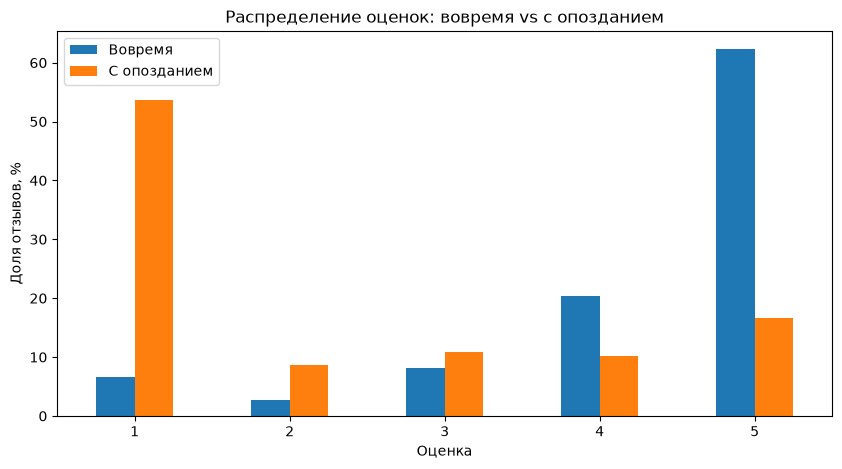

,Вовремя,С опозданием
review_score,,
1,6.6,53.7
2,2.6,8.7
3,8.1,10.9
4,20.4,10.2
5,62.3,16.6


In [18]:
#хотим посмотреть как именно меняются оценки: опоздавшие заказы чаще получают единицы или просто чуть меньше пятёрок
on_time = deliveries_reviews[deliveries_reviews['is_late'] == False]
late = deliveries_reviews[deliveries_reviews['is_late'] == True]

#доля каждой оценки от 1 до 5 внутри группы, в процентах
on_time_share = on_time['review_score'].value_counts(normalize=True).sort_index() * 100
late_share = late['review_score'].value_counts(normalize=True).sort_index() * 100

#собираем в одну таблицу и рисуем
score_share = pd.DataFrame({"Вовремя": on_time_share, "С опозданием": late_share})

score_share.plot(kind="bar", figsize=(10, 5))
plt.title("Распределение оценок: вовремя vs с опозданием")
plt.xlabel("Оценка")
plt.ylabel("Доля отзывов, %")
plt.xticks(rotation=0)
plt.show()

score_share.round(1)

**Вывод:**
- Опаздывает 6,8% заказов.
- Средняя оценка вовремя доставленных заказов — **4,29**, опоздавших — **2,27**: разница 2 балла из 5.
- Больше половины опоздавших заказов (54%) получают оценку 1, у доставленных вовремя — только 7%. Пятёрок среди опоздавших в ~4 раза меньше (17% против 62%).
- Задержка доставки — один из главных источников негативных отзывов. Сокращение опозданий или более точный прогноз срока доставки может заметно поднять оценки.